# Tier 0 · Notebook 5 — Weight Initialization & Normalization

> **Goal:** understand *why deep networks refuse to train unless you initialize them carefully* — derive **Xavier/Glorot** and **Kaiming/He** init from a single principle (keep the signal's variance constant through depth), *see* activations vanish and explode, and understand the two modern rescues: **normalization layers** and **residual connections**.

**The one idea.** A deep net is a long chain of layers. A signal (an activation on the forward pass, a gradient on the backward pass) gets multiplied by a weight matrix at every layer. If each layer shrinks the signal a little, then after 50 layers it's multiplied by (little)$^{50}$ ≈ **0** — the signal **vanishes** and nothing learns. If each layer grows it a little, after 50 layers it's (lot)$^{50}$ ≈ **∞** — it **explodes** into NaNs. The knife's edge in between — where the signal's *scale stays constant* layer after layer — is what good initialization buys you. That's the whole subject.

We'll make this concrete, derive the exact weight scale that hits the knife's edge, and then see how BatchNorm/LayerNorm and residual connections make training robust even when init isn't perfect.


## 0. Watch the signal die (and blow up)

Let's build a 50-layer deep linear→ReLU stack, push a random input through it, and record the **standard deviation of the activations at each layer** for three weight scales. Nothing is being trained here — this is pure forward signal propagation, and it already decides whether training is even possible.


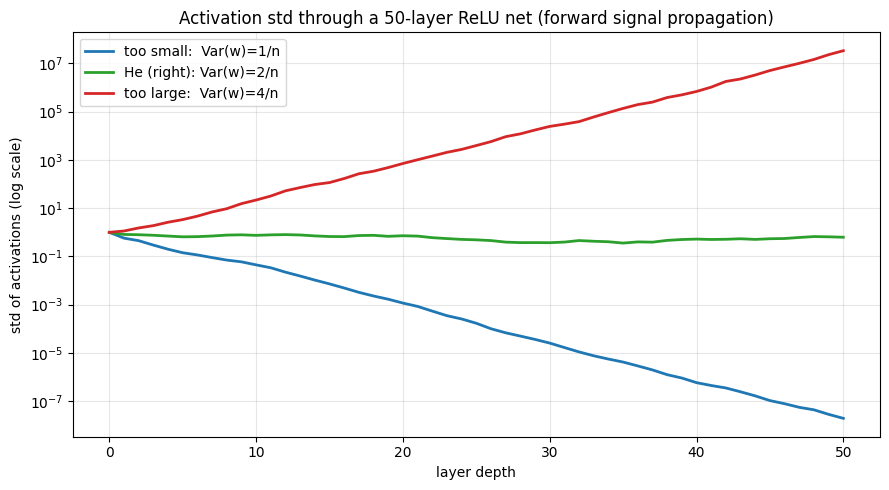

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)

def forward_stats(scale_var, depth=50, width=256, act="relu"):
    """Push a unit-variance input through `depth` layers; return std of activations per layer."""
    h = np.random.randn(width)                     # input, std ~ 1
    stds = [h.std()]
    for _ in range(depth):
        W = np.random.randn(width, width) * np.sqrt(scale_var)   # Var(w) = scale_var
        h = W @ h
        if act == "relu": h = np.maximum(0, h)
        elif act == "tanh": h = np.tanh(h)
        stds.append(h.std())
    return np.array(stds)

n = 256
fig, ax = plt.subplots(figsize=(9, 5))
for label, var, color in [("too small:  Var(w)=1/n",  1/n, "tab:blue"),
                          ("He (right): Var(w)=2/n",  2/n, "tab:green"),
                          ("too large:  Var(w)=4/n",  4/n, "tab:red")]:
    ax.plot(forward_stats(var, act="relu"), lw=2, color=color, label=label)
ax.set_yscale("log")
ax.set_title("Activation std through a 50-layer ReLU net (forward signal propagation)")
ax.set_xlabel("layer depth"); ax.set_ylabel("std of activations (log scale)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


**What to notice.** Three completely different fates, decided *only* by the weight scale:
- **Too small (blue):** the std halves roughly every layer — by layer 50 the activations are ~$10^{-8}$, numerically **dead**. Gradients through such a net are equally dead: nothing learns.
- **Too large (red):** the std grows every layer — activations blow up toward $10^{6}$ and beyond (NaN territory in fp32).
- **"He" (green):** the std stays **flat and stable** all the way down (it settles to a constant, not any particular value — what matters is it neither shrinks nor grows). The signal is preserved. *This* net can train.

The green curve is the knife's edge, and `Var(w) = 2/n` is exactly where it sits for ReLU. Let's derive *why* that number, and not `1/n` or `4/n`.


## 1. Derive the forward rule (Xavier/Glorot)

Take one linear layer $y = Wx$ (ignore bias). Component $i$ is a sum over the $n_\text{in}$ inputs:
$$y_i = \sum_{j=1}^{n_\text{in}} W_{ij}\,x_j.$$
Assume (the standard init assumptions): the weights $W_{ij}$ are i.i.d. with mean 0 and variance $\sigma_w^2$; the inputs $x_j$ are i.i.d. with mean 0 and variance $\sigma_x^2$; and weights and inputs are independent. Then each term $W_{ij}x_j$ has mean 0 and, since the two factors are independent and zero-mean,
$$\text{Var}(W_{ij}x_j) = \mathbb{E}[W_{ij}^2]\,\mathbb{E}[x_j^2] = \sigma_w^2\,\sigma_x^2.$$
The $y_i$ is a sum of $n_\text{in}$ independent such terms, and variances of independent variables add:
$$\text{Var}(y_i) = n_\text{in}\,\sigma_w^2\,\sigma_x^2.$$
**To preserve the signal scale we want $\text{Var}(y) = \text{Var}(x)$**, i.e. $n_\text{in}\,\sigma_w^2 = 1$, giving the **forward** rule:
$$\boxed{\sigma_w^2 = \frac{1}{n_\text{in}}}.$$
This is **Xavier/Glorot** init (for linear or tanh layers, where tanh ≈ identity near 0). The backward pass gives the mirror-image condition $\sigma_w^2 = 1/n_\text{out}$ (to preserve *gradient* variance), and since you usually can't satisfy both, Glorot's paper takes the harmonic-ish compromise $\sigma_w^2 = \frac{2}{n_\text{in}+n_\text{out}}$.

Let's confirm the core formula $\text{Var}(y) = n_\text{in}\sigma_w^2\sigma_x^2$ empirically:


In [2]:
n_in, n_out = 512, 300
sig_w2, sig_x2 = 0.01, 4.0
W = np.random.randn(n_out, n_in) * np.sqrt(sig_w2)
X = np.random.randn(n_in, 5000) * np.sqrt(sig_x2)
Y = W @ X
predicted = n_in * sig_w2 * sig_x2
print(f"predicted Var(y) = n_in * σw² * σx² = {predicted:.3f}")
print(f"measured  Var(y)                    = {Y.var():.3f}")
print(f"ratio measured/predicted            = {Y.var()/predicted:.4f}")


predicted Var(y) = n_in * σw² * σx² = 20.480
measured  Var(y)                    = 20.412
ratio measured/predicted            = 0.9967


**What to notice.** Measured variance matches the formula to ~1%. So the compounding is exactly multiplicative: after $L$ layers the variance is multiplied by $(n_\text{in}\sigma_w^2)^L$. Set that per-layer factor to **1** and the signal is stable; anything else and it vanishes ($<1$) or explodes ($>1$) *exponentially* in depth. This is the mathematical statement of the three curves above.


## 2. ReLU eats half the *second moment* → Kaiming/He

Xavier assumed a linear (or near-linear) activation. **ReLU is not linear** — it zeros out every negative input. Here's the subtlety that trips people up: because the ReLU output is **no longer zero-mean** (all the negatives became 0, so the mean is positive), the clean bookkeeping quantity is *not* the variance but the **second moment** $\mathbb{E}[x^2]$. For zero-mean symmetric $z$, keeping only the positive half gives *exactly*
$$\mathbb{E}[\text{ReLU}(z)^2] = \int_0^\infty z^2\,p(z)\,dz = \tfrac12\int_{-\infty}^\infty z^2\,p(z)\,dz = \tfrac12\,\mathbb{E}[z^2].$$
The second moment halves — cleanly, no $\pi$'s. And it's the second moment that enters the propagation recursion: for pre-activation $y = Wx$, $\text{Var}(y) = n_\text{in}\,\sigma_w^2\,\mathbb{E}[x^2]$, and since the previous pre-activation was zero-mean, $\mathbb{E}[x^2] = \mathbb{E}[\text{ReLU}(\text{pre})^2] = \tfrac12\text{Var}(\text{pre})$. So the per-layer factor is $\tfrac12 n_\text{in}\sigma_w^2$, and preserving it (=1) needs a weight variance twice as large:
$$\boxed{\sigma_w^2 = \frac{2}{n_\text{in}}}\quad\text{(Kaiming/He init, for ReLU).}$$
That factor of 2 is the entire difference between Xavier and He — and using Xavier (the $1/n$ blue curve) with ReLU is exactly why the signal died above. Let's verify the clean **second-moment** halving directly (and also look at the *variance* ratio, which is a messier number):


E[ReLU(z)^2] / E[z^2]   = 0.500   <- the clean 1/2 (drives He init)
Var(ReLU(z)) / Var(z)   = 0.341   (= 1/2 - 1/(2*pi) ≈ 0.341; smaller, due to the nonzero mean)
mean introduced by ReLU = 1.196   (was 0 before)


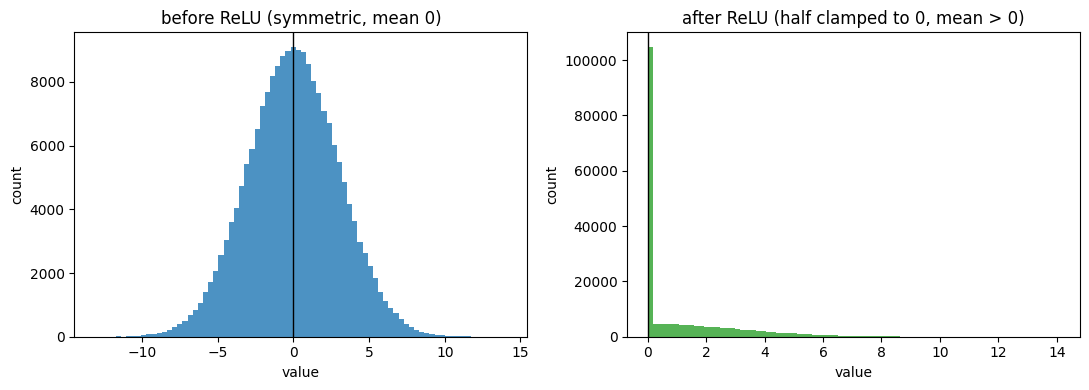

In [3]:
z = np.random.randn(200000) * 3.0     # zero-mean symmetric, Var = 9
relu_z = np.maximum(0, z)
second_moment_ratio = (relu_z**2).mean() / (z**2).mean()
variance_ratio      = relu_z.var() / z.var()
print(f"E[ReLU(z)^2] / E[z^2]   = {second_moment_ratio:.3f}   <- the clean 1/2 (drives He init)")
print(f"Var(ReLU(z)) / Var(z)   = {variance_ratio:.3f}   (= 1/2 - 1/(2*pi) ≈ 0.341; smaller, due to the nonzero mean)")
print(f"mean introduced by ReLU = {relu_z.mean():.3f}   (was 0 before)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(z, bins=80, color="tab:blue", alpha=0.8); ax[0].set_title("before ReLU (symmetric, mean 0)")
ax[1].hist(relu_z, bins=80, color="tab:green", alpha=0.8); ax[1].set_title("after ReLU (half clamped to 0, mean > 0)")
for a in ax: a.set_xlabel("value"); a.set_ylabel("count"); a.axvline(0, color="k", lw=1)
plt.tight_layout(); plt.show()


**What to notice.** Exactly half the mass gets clamped to the spike at 0, and the measured **second-moment** ratio is ~0.5 — the clean factor that forces the "2" in $2/n_\text{in}$. The *variance* ratio is only ~0.34, because ReLU also shifts the mean positive (printed above) and variance subtracts off that mean; that's why the He derivation is careful to track $\mathbb{E}[x^2]$, not $\text{Var}(x)$. Getting this exactly right is the difference between reciting a formula and understanding it. The rule to recite: **ReLU → He init ($2/n$); tanh/linear → Xavier ($1/n$).**


## 3. The activation-distribution-by-depth picture

The std-vs-depth line plot compressed each layer to one number. Let's see the *full distributions* at several depths, comparing the wrong init (Xavier $1/n$ with ReLU) to the right one (He $2/n$). This is the canonical diagnostic figure you'd plot when debugging a net that won't train.


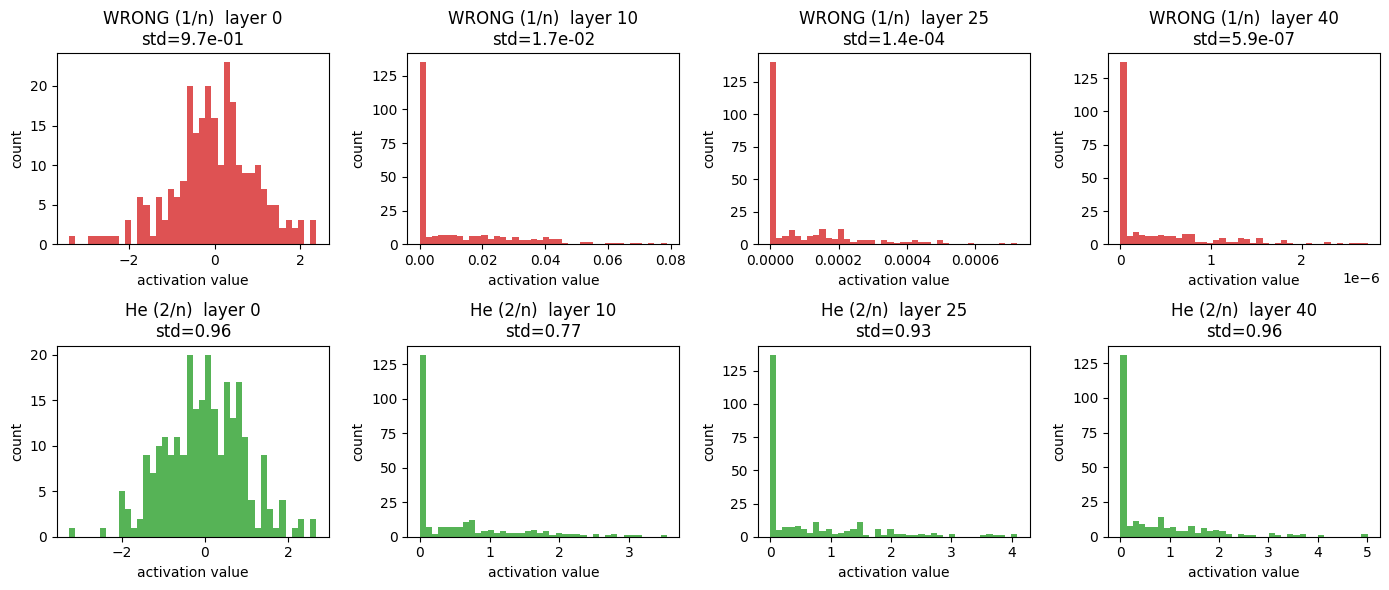

In [4]:
def layer_hists(scale_var, depth=40, width=256):
    h = np.random.randn(width)
    snaps = {0: h.copy()}
    for l in range(1, depth+1):
        W = np.random.randn(width, width) * np.sqrt(scale_var)
        h = np.maximum(0, W @ h)
        if l in (10, 25, 40): snaps[l] = h.copy()
    return snaps

wrong = layer_hists(1/256)   # Xavier with ReLU -> vanishes
right = layer_hists(2/256)   # He -> stable
depths = [0, 10, 25, 40]

fig, ax = plt.subplots(2, 4, figsize=(14, 6))
for j, d in enumerate(depths):
    ax[0, j].hist(wrong[d], bins=40, color="tab:red",   alpha=0.8)
    ax[0, j].set_title(f"WRONG (1/n)  layer {d}\nstd={wrong[d].std():.1e}")
    ax[1, j].hist(right[d], bins=40, color="tab:green", alpha=0.8)
    ax[1, j].set_title(f"He (2/n)  layer {d}\nstd={right[d].std():.2f}")
    for r in (0, 1):
        ax[r, j].set_xlabel("activation value"); ax[r, j].set_ylabel("count")
plt.tight_layout(); plt.show()


**What to notice.** Top row (wrong init): the distribution collapses toward a spike at 0 — by layer 40 the std is ~$10^{-5}$, the activations are numerically indistinguishable from zero, and the network is a dead wire. Bottom row (He init): the distribution keeps a healthy spread (std ≈ 0.7–1) at every depth. Same architecture, same data, *only the initialization variance differs* — and one trains while the other is a brick. When someone says "my deep net won't learn," this histogram-by-depth is the first thing to check.


## 4. The backward pass vanishes too (gradient flow)

Everything above was the *forward* signal. The **gradient** flowing backward obeys the same law with the transpose: $\bar x = W^{\mathsf T}\bar y$, so gradient variance is multiplied by $n_\text{out}\sigma_w^2$ per layer. Bad init makes **gradients** vanish or explode just like activations — and vanishing gradients are the direct reason a deep net's early layers stop learning. Let's measure gradient std by depth under good vs bad init.


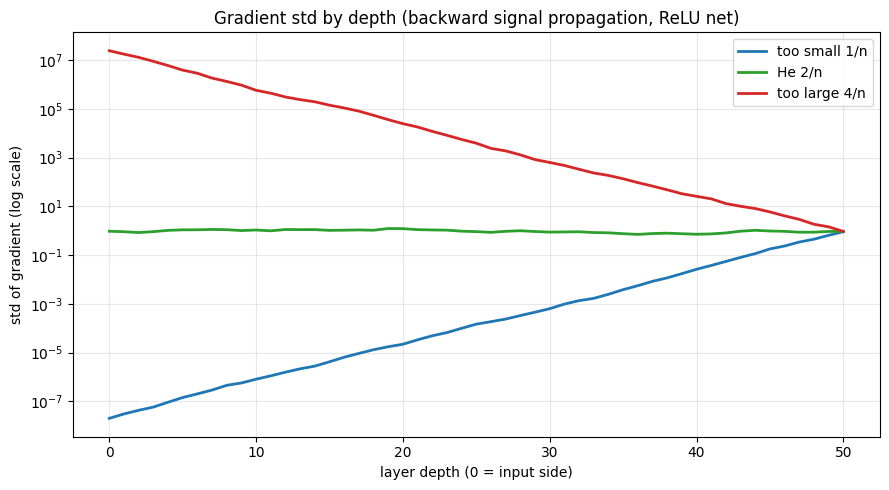

In [5]:
def backward_grad_stds(scale_var, depth=50, width=256):
    # forward (store pre-activations), then backprop a random upstream gradient
    hs, zs, Ws = [np.random.randn(width)], [], []
    for _ in range(depth):
        W = np.random.randn(width, width) * np.sqrt(scale_var)
        z = W @ hs[-1]; Ws.append(W); zs.append(z)
        hs.append(np.maximum(0, z))
    dh = np.random.randn(width)            # gradient at the output
    grad_stds = [dh.std()]
    for l in reversed(range(depth)):
        dz = dh * (zs[l] > 0)              # through ReLU
        dh = Ws[l].T @ dz                  # through the linear layer
        grad_stds.append(dh.std())
    return np.array(grad_stds[::-1])       # index by layer (input .. output)

fig, ax = plt.subplots(figsize=(9, 5))
for label, var, c in [("too small 1/n", 1/256, "tab:blue"),
                      ("He 2/n",        2/256, "tab:green"),
                      ("too large 4/n", 4/256, "tab:red")]:
    ax.plot(backward_grad_stds(var), lw=2, color=c, label=label)
ax.set_yscale("log")
ax.set_title("Gradient std by depth (backward signal propagation, ReLU net)")
ax.set_xlabel("layer depth (0 = input side)"); ax.set_ylabel("std of gradient (log scale)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


**What to notice.** Same three fates for the gradient. With the too-small init (blue) the gradient at the *input-side* layers (left) is astronomically smaller than at the output — those early layers receive essentially **no** learning signal, so they never update. This "vanishing gradient" is why, pre-2015, networks deeper than ~20 layers were nearly untrainable, and why the two innovations in the next sections were such a big deal. He init (green) keeps the gradient roughly flat across all depths — every layer learns.


## 5. Normalization: robustness to init (recap from Notebook 3)

Careful init keeps the signal alive *at step 0*, but during training the weights move and the balance can drift. **Normalization layers** (BatchNorm, LayerNorm — built in Notebook 3) attack this directly: they re-standardize activations to mean 0 / unit variance *at every forward pass*, so the signal can't vanish or explode no matter what the weights do. In effect, normalization makes the network far **less sensitive to initialization**. Let's demonstrate: take the badly-initialized net (whose activations died in §0) and drop a LayerNorm after each layer.


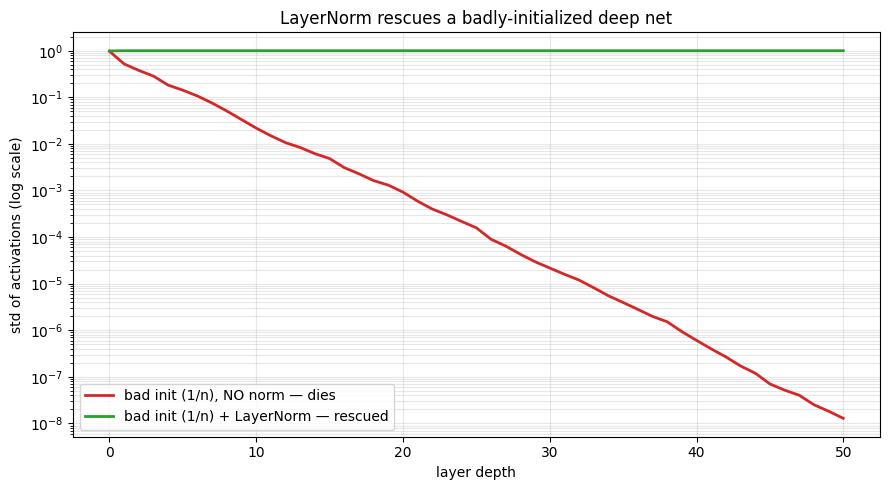

In [6]:
def layernorm(h, eps=1e-5):
    return (h - h.mean()) / np.sqrt(h.var() + eps)

def forward_stats_ln(scale_var, use_ln, depth=50, width=256):
    h = np.random.randn(width); stds = [h.std()]
    for _ in range(depth):
        W = np.random.randn(width, width) * np.sqrt(scale_var)
        h = np.maximum(0, W @ h)
        if use_ln: h = layernorm(h)
        stds.append(h.std())
    return np.array(stds)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(forward_stats_ln(1/256, use_ln=False), lw=2, color="tab:red",  label="bad init (1/n), NO norm — dies")
ax.plot(forward_stats_ln(1/256, use_ln=True),  lw=2, color="tab:green", label="bad init (1/n) + LayerNorm — rescued")
ax.set_yscale("log")
ax.set_title("LayerNorm rescues a badly-initialized deep net")
ax.set_xlabel("layer depth"); ax.set_ylabel("std of activations (log scale)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


**What to notice.** Without normalization (red) the badly-scaled net's activations collapse toward zero, exactly as before. Add LayerNorm (green) and the std is pinned near 1 at every depth *despite the bad init* — the normalization simply re-establishes the scale each layer, so the exponential decay never gets to compound. This is a big part of why modern architectures are so forgiving about initialization: the norm layer does the variance bookkeeping for you. (It doesn't make init *irrelevant* — good init still speeds early training — but it removes the catastrophe.)


## 6. Residual connections: gradient highways

The second great rescue. A **residual** (skip) connection computes $h_{\ell} = h_{\ell-1} + F(h_{\ell-1})$ instead of $h_{\ell} = F(h_{\ell-1})$ — it *adds* the layer's output to its input rather than replacing it. Look at what that does to the **backward** pass. Differentiating $h_\ell = h_{\ell-1} + F(h_{\ell-1})$:
$$\frac{\partial L}{\partial h_{\ell-1}} = \frac{\partial L}{\partial h_\ell}\Big(1 + F'(h_{\ell-1})\Big) = \underbrace{\frac{\partial L}{\partial h_\ell}}_{\text{the "1": highway}} + \underbrace{\frac{\partial L}{\partial h_\ell}F'}_{\text{the transformed part}}.$$
That **"+1"** means the gradient has a path straight back through the skip connection, **undiminished** — even if the $F'$ term shrinks to zero, the gradient still flows. Stack many residual blocks and the gradient can travel from the loss to the very first layer without vanishing. This single trick (ResNet, 2015) is what unlocked networks with *hundreds* of layers, and every transformer is a stack of residual blocks. Let's measure it.


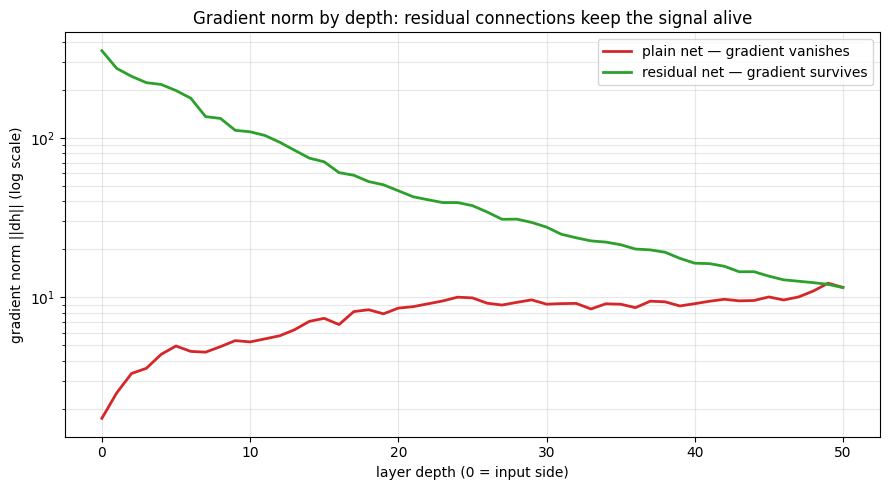

In [7]:
def grad_norms_by_depth(residual, depth=50, width=128, scale_var=1/128):
    # tanh net (saturates -> plain version vanishes); measure ||dh|| at each depth
    hs, zs, Ws = [np.random.randn(width)], [], []
    for _ in range(depth):
        W = np.random.randn(width, width) * np.sqrt(scale_var)
        z = W @ hs[-1]; Ws.append(W); zs.append(z)
        f = np.tanh(z)
        hs.append(hs[-1] + f if residual else f)
    dh = np.random.randn(width); norms = [np.linalg.norm(dh)]
    for l in reversed(range(depth)):
        df = dh * (1 - np.tanh(zs[l])**2)      # through tanh
        dh_prev = Ws[l].T @ df
        dh = (dh + dh_prev) if residual else dh_prev   # "+dh" = the skip highway
        norms.append(np.linalg.norm(dh))
    return np.array(norms[::-1])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grad_norms_by_depth(residual=False), lw=2, color="tab:red",   label="plain net — gradient vanishes")
ax.plot(grad_norms_by_depth(residual=True),  lw=2, color="tab:green", label="residual net — gradient survives")
ax.set_yscale("log")
ax.set_title("Gradient norm by depth: residual connections keep the signal alive")
ax.set_xlabel("layer depth (0 = input side)"); ax.set_ylabel("gradient norm ||dh|| (log scale)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


**What to notice.** In the plain net (red) the gradient norm decays by many orders of magnitude from output to input — the early layers are starved. In the residual net (green) the "+1" highway keeps the gradient norm roughly **flat** across all 50 layers: the signal reaches the first layer essentially intact. That is the mechanism behind ResNets and transformers being trainable at extreme depth. Notice we didn't even change the init here — residual connections give you depth-robustness *on top of* whatever init you chose.


## 7. Verify our init against `torch.nn.init`

Finally, confirm the numbers: sample weights with our formulas and with PyTorch's official initializers, and check the empirical standard deviations agree with theory.


In [8]:
import torch
import torch.nn.init as tinit

fan_in, fan_out = 512, 256

# --- Kaiming/He (ReLU): theory std = sqrt(2 / fan_in) ---
ours_he  = (np.random.randn(fan_out, fan_in) * np.sqrt(2.0/fan_in)).std()
t = torch.empty(fan_out, fan_in); tinit.kaiming_normal_(t, nonlinearity="relu")
print("Kaiming/He (ReLU):")
print(f"    theory std        = {np.sqrt(2.0/fan_in):.5f}")
print(f"    ours              = {ours_he:.5f}")
print(f"    torch kaiming_    = {t.std().item():.5f}")

# --- Xavier/Glorot: theory std = sqrt(2 / (fan_in + fan_out)) ---
xg = np.sqrt(2.0/(fan_in+fan_out))
ours_xg = (np.random.randn(fan_out, fan_in) * xg).std()
t2 = torch.empty(fan_out, fan_in); tinit.xavier_normal_(t2)
print("Xavier/Glorot:")
print(f"    theory std        = {xg:.5f}")
print(f"    ours              = {ours_xg:.5f}")
print(f"    torch xavier_     = {t2.std().item():.5f}")

assert abs(ours_he - np.sqrt(2.0/fan_in)) < 2e-3
assert abs(t.std().item() - np.sqrt(2.0/fan_in)) < 2e-3
print("\n✅ our init scales match theory and torch.nn.init")


Kaiming/He (ReLU):
    theory std        = 0.06250
    ours              = 0.06256
    torch kaiming_    = 0.06242
Xavier/Glorot:
    theory std        = 0.05103
    ours              = 0.05101
    torch xavier_     = 0.05108

✅ our init scales match theory and torch.nn.init


**What to notice.** Our from-scratch scales match both the theoretical formula and PyTorch's `kaiming_normal_` / `xavier_normal_` to ~1e-3 (the residual noise is just finite-sample variation in the std estimate). So the one-line rules — `randn * sqrt(2/fan_in)` for ReLU, `randn * sqrt(2/(fan_in+fan_out))` for tanh/linear — *are* what the framework does under the hood.

## 8. What you built

| Concept | Rule / mechanism | Why |
|---|---|---|
| **Signal propagation** | per-layer variance factor $n\sigma_w^2$ | =1 stable, <1 vanish, >1 explode (exponential in depth) |
| **Xavier/Glorot** | $\sigma_w^2 = 1/n$ (or $2/(n_\text{in}{+}n_\text{out})$) | preserve variance for **linear/tanh** |
| **Kaiming/He** | $\sigma_w^2 = 2/n_\text{in}$ | the extra 2 because **ReLU halves variance** |
| **Normalization** | re-standardize each layer | robustness to init, no compounding drift |
| **Residual** | $h=h+F(h)$ → gradient "+1" highway | trainable at hundreds of layers |

The through-line: deep learning is a game of **keeping variance ~1 through depth**, on both the forward and backward pass. Init sets it right at step 0; normalization maintains it during training; residuals give the gradient a shortcut that can't vanish.

## 9. Exercises
1. **Derive the ReLU 1/2.** Show the *second moment* halves: $\mathbb{E}[\max(0,z)^2] = \tfrac12\mathbb{E}[z^2]$ for zero-mean symmetric $z$. Then show the *variance* is the messier $\text{Var}(\max(0,z)) = (\tfrac12 - \tfrac1{2\pi})\text{Var}(z)$ by computing the nonzero mean $\mathbb{E}[\max(0,z)] = \sigma/\sqrt{2\pi}$ — and explain why He init uses the second moment, not the variance.
2. **fan_in vs fan_out.** Rerun the forward/backward std plots with $\sigma_w^2 = 1/n_\text{out}$ instead of $1/n_\text{in}$. Which pass is preserved now, and which drifts?
3. **Sigmoid init.** Sigmoid isn't zero-mean. Why does that break the variance argument, and what practical trick (used historically) partly rescues it?
4. **How deep before it dies?** For $\sigma_w^2 = 1/n$ with ReLU, predict the depth at which activation std drops below fp32's smallest normal (~$10^{-38}$), then verify.
5. **Residual + bad init.** Combine a residual net with the too-small init and check the gradient-by-depth plot. Does the highway rescue it? What does that tell you about why transformers are init-forgiving?
6. **LSUV / data-dependent init.** Read about "all-you-need-is-a-good-init" (LSUV): initialize, then rescale each layer's weights so its *measured* output variance is exactly 1. Implement it for the 50-layer net.

## 10. Interview / residency framing
- *"Why do we need careful initialization?"* → per-layer variance factor compounds exponentially with depth; off-by-a-little ⇒ vanish/explode; derive $n\sigma_w^2$.
- *"Xavier vs Kaiming — when and why the factor of 2?"* → Xavier for linear/tanh ($1/n$); Kaiming for ReLU ($2/n$) because ReLU halves the variance.
- *"How do BatchNorm/LayerNorm help with init?"* → they re-standardize activations each forward pass, so variance can't compound away; makes training robust to init.
- *"Why do residual connections let us train very deep nets?"* → the skip adds a "+1" term to the backward Jacobian, an undiminished gradient highway; derive $\partial h_\ell/\partial h_{\ell-1} = 1 + F'$.
- *"You have a 100-layer net that won't learn — what do you check?"* → activation/gradient std by depth; init scale vs activation type; presence of norm and residuals.

---
**Next (Tier 1):** *Notebook 6 — MLP end-to-end*: assemble autograd + layers + optimizer + init into a full training pipeline on a real dataset (MNIST), with train/val curves, overfitting, and regularization — the first "put it all together" notebook.


## 📚 References & papers

This notebook reproduces / builds on:

- **Understanding the difficulty of training deep feedforward networks (Xavier/Glorot init)** — Glorot & Bengio (2010), AISTATS.
- **Delving Deep into Rectifiers (Kaiming/He init)** — He et al. (2015), arXiv:1502.01852.
- **Deep Residual Learning for Image Recognition (ResNet)** — He et al. (2015), arXiv:1512.03385.